# N10 Model on Small Cluster Sizes

The N10 model was trained with exactly 10 reads (observation_size=10, lower_bound=10).
It breaks down on cluster size 2. Why?

Unlike the N2 model, the N10 model has trained positional embeddings for all positions 0-1100+.
But during training, the `:` token (generation trigger) was always at position ~1100.
With cluster size 2, `:` appears at position ~200, a position the model associates with
nucleotides in the middle of reads, not the start of generation.

**Hypothesis:** The model learned position-dependent token semantics. Position ~200 means
'I am inside a read', not 'start generating'. The `:` representation at position 200 is
fundamentally different from `:` at position 1100.

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

%matplotlib inline
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys, pickle, random
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from src.gpt_pkg.model import GPT, GPTConfig
from src.data_pkg.IDS_channel import IDS_channel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with open('/workspaces/TReconLM/src/data_pkg/meta_nuc.pkl', 'rb') as f:
    meta = pickle.load(f)
stoi, itos = meta['stoi'], meta['itos']
encode_str = lambda s: [stoi[ch] for ch in s]

channel_stats = {'substitution_probability': 0.05, 'deletion_probability': 0.05, 'insertion_probability': 0.05}

# Load N10 model
ckpt_path = '/mnt/model_checkpoints/FixedN/N10/checkpoint_best.pt'
ckpt = torch.load(ckpt_path, map_location=device)
state_dict = {k.replace('_orig_mod.', ''): v for k, v in ckpt['model'].items()}
config_args = {k: v for k, v in ckpt['model_args'].items() if k != 'model_type'}
model = GPT(GPTConfig(**config_args))
model.load_state_dict(state_dict, strict=True)
model = model.to(device).eval()
print(f'N10 model loaded on {device}')

pos_emb = state_dict['transformer.wpe.weight'].float().cpu().numpy()
wte = state_dict['transformer.wte.weight'].float().cpu().numpy()
print(f'Pos emb shape: {pos_emb.shape}')

FlashAttention available (will be used during training and inference with KV cache)
N10 model loaded on cuda
Pos emb shape: (1500, 512)


##The `:` token: what does its representation look like for different cluster sizes?


In [2]:
from sklearn.metrics.pairwise import cosine_similarity

cluster_sizes = [2, 3, 4, 5, 6, 7, 8, 9, 10]
n_examples = 100

colon_id = stoi[':']
colon_data = {cs: {'vecs': [], 'norms': [], 'positions': []} for cs in cluster_sizes}

for cs in cluster_sizes:
    for ex_idx in range(n_examples):
        rng = random.Random(1000 * cs + ex_idx)
        gt = ''.join(rng.choice('ACGT') for _ in range(110))
        reads = [IDS_channel(gt, channel_stats, rng) for _ in range(cs)]
        input_str = '|'.join(reads) + ':'
        tokens = encode_str(input_str)
        colon_pos = len(tokens) - 1
        vec = wte[colon_id] + pos_emb[colon_pos]
        colon_data[cs]['vecs'].append(vec)
        colon_data[cs]['norms'].append(np.linalg.norm(vec))
        colon_data[cs]['positions'].append(colon_pos)

# Reference: mean ':' vector at CS10 (in-distribution)
cs10_mean = np.array(colon_data[10]['vecs']).mean(axis=0)

# For each CS: cosine similarity of its mean ':' vector to the CS10 mean
print(f"{'CS':>3} | {'Mean pos of :':>13} | {'Norm':>18} | {'Cos sim to CS10 :'}")
print('-' * 65)
for cs in cluster_sizes:
    cs_mean = np.array(colon_data[cs]['vecs']).mean(axis=0)
    cos_to_cs10 = cosine_similarity(cs_mean.reshape(1, -1), cs10_mean.reshape(1, -1))[0, 0]
    norms_arr = np.array(colon_data[cs]['norms'])
    pos_arr = np.array(colon_data[cs]['positions'])
    marker = ' <-- in-distribution' if cs == 10 else ''
    print(f"{cs:>3} | {pos_arr.mean():>10.0f} \u00b1 {pos_arr.std():>2.0f} | "
          f"{norms_arr.mean():.4f} \u00b1 {norms_arr.std():.4f} | "
          f"{cos_to_cs10:.4f}{marker}")


 CS | Mean pos of : |               Norm | Cos sim to CS10 :
-----------------------------------------------------------------
  2 |        221 ±  5 | 1.3649 ± 0.0426 | 0.8643
  3 |        331 ±  6 | 1.3651 ± 0.0504 | 0.8768
  4 |        443 ±  7 | 1.3708 ± 0.0494 | 0.9051
  5 |        553 ±  7 | 1.3866 ± 0.0435 | 0.9080
  6 |        663 ±  8 | 1.3543 ± 0.0450 | 0.9230
  7 |        775 ±  8 | 1.3575 ± 0.0697 | 0.9294
  8 |        888 ±  9 | 1.3464 ± 0.0525 | 0.9121
  9 |        999 ± 10 | 1.2131 ± 0.0902 | 0.9057
 10 |       1108 ± 11 | 1.1145 ± 0.0384 | 1.0000 <-- in-distribution


### Causal test: replace `:` embedding with CS10 positional embedding

We surgically replace just the `:` token's positional embedding with the one it
would have at CS10 (position ~1108). We test three conditions:
1. **Normal** - no changes
2. **`:` fix** - only fix the `:` token's position
3. **`:` + gen fix** - fix `:` AND give generated tokens CS10-like positions

In [3]:
from Levenshtein import distance as lev_dist
import torch.nn.functional as F
from tqdm.notebook import tqdm

CS10_COLON_POS = 1108

def generate_with_colon_fix(model, input_str, device, fix_colon_pos=None, fix_gen_pos=False, max_new_tokens=110):
    tokens = encode_str(input_str)
    input_len = len(tokens)
    colon_idx = input_len - 1
    x = torch.tensor([tokens], dtype=torch.long, device=device)
    attn_mask = torch.ones(1, input_len, dtype=torch.bool, device=device)
    with torch.no_grad():
        pos = (attn_mask.long().cumsum(-1) - 1).clamp(min=0)
        h = model.transformer.wte(x) + model.transformer.wpe(pos)
        if fix_colon_pos is not None:
            colon_wte = model.transformer.wte(torch.tensor([[stoi[':']]], device=device))
            colon_wpe = model.transformer.wpe(torch.tensor([[fix_colon_pos]], device=device))
            h[0, colon_idx, :] = (colon_wte + colon_wpe)[0, 0, :]
        h = model.transformer.drop(h)
        caches = []
        for block in model.transformer.h:
            h, cache = block(h, attn_mask=attn_mask, cache=None)
            caches.append(cache)
        h = model.transformer.ln_f(h)
        generated = []
        gen_step = 0
        for step in range(max_new_tokens):
            logits = model.lm_head(h[:, -1:, :])[:, 0, :]
            next_token = logits.argmax(dim=-1, keepdim=True)
            if itos[next_token.item()] not in {'A', 'C', 'G', 'T'}:
                for alt in torch.sort(F.softmax(logits, dim=-1)[0], descending=True)[1]:
                    if itos[alt.item()] in {'A', 'C', 'G', 'T'}:
                        next_token = alt.unsqueeze(0).unsqueeze(0)
                        break
            generated.append(next_token.item())
            attn_mask = torch.cat([attn_mask, torch.ones(1, 1, dtype=torch.bool, device=device)], dim=1)
            if fix_gen_pos and fix_colon_pos is not None:
                gen_pos = torch.tensor([[fix_colon_pos + 1 + gen_step]], device=device)
            else:
                gen_pos = (attn_mask.long().cumsum(-1) - 1).clamp(min=0)[:, -1:]
            h_next = model.transformer.wte(next_token) + model.transformer.wpe(gen_pos)
            h_next = model.transformer.drop(h_next)
            for i, block in enumerate(model.transformer.h):
                h_next, caches[i] = block(h_next, attn_mask=attn_mask, cache=caches[i])
            h = model.transformer.ln_f(h_next)
            gen_step += 1
    return ''.join(itos[t] for t in generated)

n_examples = 50
test_cluster_sizes = [2, 3, 5, 10]

header = f"{'CS':>3} | {'Normal FR':>10} | {'Normal LEV':>10} | {':fix FR':>10} | {':fix LEV':>10} | {':+gen fix FR':>12} | {':+gen fix LEV':>13}"
print(header)
print('-' * 95)

for cs in tqdm(test_cluster_sizes, desc='Cluster sizes'):
    normal_levs, colon_levs, both_levs = [], [], []
    for ex_idx in tqdm(range(n_examples), desc=f'CS={cs}', leave=False):
        rng = random.Random(3000 * cs + ex_idx)
        gt = ''.join(rng.choice('ACGT') for _ in range(110))
        reads = [IDS_channel(gt, channel_stats, rng) for _ in range(cs)]
        input_str = '|'.join(reads) + ':'
        pred_n = generate_with_colon_fix(model, input_str, device)
        pred_c = generate_with_colon_fix(model, input_str, device, fix_colon_pos=CS10_COLON_POS)
        pred_b = generate_with_colon_fix(model, input_str, device, fix_colon_pos=CS10_COLON_POS, fix_gen_pos=True)
        normal_levs.append(lev_dist(gt, pred_n[:110]) / 110)
        colon_levs.append(lev_dist(gt, pred_c[:110]) / 110)
        both_levs.append(lev_dist(gt, pred_b[:110]) / 110)
        print(f'  CS{cs} ex{ex_idx}: normal={normal_levs[-1]:.3f} :fix={colon_levs[-1]:.3f} :+gen={both_levs[-1]:.3f}')
        print(f'    [GT]     {gt}')
        print(f'    [NORMAL] {pred_n[:110]}')
        print(f'    [:FIX]   {pred_c[:110]}')
        print(f'    [:+GEN]  {pred_b[:110]}')
    nfr = np.mean([l > 0 for l in normal_levs]) * 100
    cfr = np.mean([l > 0 for l in colon_levs]) * 100
    bfr = np.mean([l > 0 for l in both_levs]) * 100
    print(f"{cs:>3} | {nfr:>9.1f}% | {np.mean(normal_levs):>10.4f} | {cfr:>9.1f}% | {np.mean(colon_levs):>10.4f} | {bfr:>11.1f}% | {np.mean(both_levs):>13.4f}")

print('\nExample CS2 predictions:')
print('=' * 80)
for ex_idx in range(3):
    rng = random.Random(3000 * 2 + ex_idx)
    gt = ''.join(rng.choice('ACGT') for _ in range(110))
    reads = [IDS_channel(gt, channel_stats, rng) for _ in range(2)]
    input_str = '|'.join(reads) + ':'
    pred_n = generate_with_colon_fix(model, input_str, device)
    pred_c = generate_with_colon_fix(model, input_str, device, fix_colon_pos=CS10_COLON_POS)
    pred_b = generate_with_colon_fix(model, input_str, device, fix_colon_pos=CS10_COLON_POS, fix_gen_pos=True)
    print(f'[GT]        {gt}')
    print(f'[NORMAL]    {pred_n[:110]}')
    print(f'[:FIX]      {pred_c[:110]}')
    print(f'[:+GEN FIX] {pred_b[:110]}')
    print()


 CS |  Normal FR | Normal LEV |    :fix FR |   :fix LEV | :+gen fix FR | :+gen fix LEV
-----------------------------------------------------------------------------------------------


Cluster sizes:   0%|          | 0/4 [00:00<?, ?it/s]

CS=2:   0%|          | 0/50 [00:00<?, ?it/s]

  CS2 ex0: normal=0.373 :fix=0.400 :+gen=0.336
    [GT]     CGCCGCATGGTTTGGAGAGTTGAGCACGAGTTTGCATCATGTAATGCATTAGTTGCTCAGCAAACAGTTCACCACCTTCTTTGATCCTGGTGCATGTCTTCATGTATCTA
    [NORMAL] CGCCGCACTGGTTTCGACACTAACCACAAGTTCAAACATGTAATGCAGTAACTCCAACACAAAAAAATAACAACATACTTTCATCCTGTCACAACCATCAACAAACAAAC
    [:FIX]   CGCCGCACTGGTTTCGAAACTTCAGCACGAGTTCAAACATGTAATGCAGTAACTCCAACACAAAAAAACACAAACATCAATCACACAAAATCAAACCACCAACAAACACA
    [:+GEN]  CGCCGCACTGGTTTCAACACTCAGAACGAGTTCAAACATGTAATGAACAACAACTAAATCACAAAAAAATAACAACATTCTTTCATCCTGGTGCATGCTCACACACAACA
  CS2 ex1: normal=0.627 :fix=0.500 :+gen=0.500
    [GT]     GCATCGGCTTTCTAGTTTGTAACAGAATATGCTTCCTTGCCCTTACAGTGTTGGAGAGGCCTCGAATATATTTTGCAGGGCTGGAGGATGGATCGGACTGACGATTGGGT
    [NORMAL] CACCCAAATTAACACACACACACAACAACACACAAAAACCAATCCAATACCCAAACAGTGTTCCACACCAACATAAATCAAAATAAATAACAACCAAACAAACAAAAAAC
    [:FIX]   CATCGCAATCAACTTCAATAACAAACAACACACACAATCCCCATACAGTGTTGGAGAGGCCTCAACAAACATCACAACCAACATAACACCAACCAAAAACAAAAAACAAA
    [:+GEN]  CATCGCAATCAACTTTCTAAAAACA

CS=3:   0%|          | 0/50 [00:00<?, ?it/s]

  CS3 ex0: normal=0.209 :fix=0.200 :+gen=0.191
    [GT]     GGACTTCTGTTAACACCGTTGGAGGCTCAATTCGATCCGGAGCTATCTTACGAGGCTGTTTCGTTGGAGCGGAATGGAGTCCCAGTCCTGGATATGACTTCGATAAACCG
    [NORMAL] GGACTTCTGTTAACACCGTTGGAGGCTCAAATCGATCTGAATCAATCAACAAGGATGTTCGTTGGAGCGGAATAAGAATCCCAGTCCTGAAAAACTCAAATAAACCAGAA
    [:FIX]   GGACTTCTGTTAACACCGTTGGAGGCTCAAATCGATCTGAATCAATCAACAAGGATGTTCGTTGGAGCGGAATAAGAGTCCCAGTCCTGAAAAACTCAAATAAACCAGAA
    [:+GEN]  GGACTTCTGTTAACACCGTTGGAGGCTCAATCGATCTGAATCAATCTACGAGGCTGTTCGTTGGAGCGGAATAAGAGTCCAGTCCTGATGACTACTATAACCGAACCGAG
  CS3 ex1: normal=0.073 :fix=0.073 :+gen=0.082
    [GT]     AGGAGAGGGATCTTCCTCGCCTTGCGTATACATGATGACGGGGAGTAGTTACTAAACGGTCGCGATTTCCTCCCCCAGTCGCCACAACTGCGCTTTCCTTAGACCACTGC
    [NORMAL] AAGGAGAGGGAATCTTCCTCGCTTGCGTATACATATCACGGGGAGTAGTTACTAAACGGTCGCGATTTCTCTCCCCAGTCGCCACAACTACGCTTTCCTTAGACCACTGC
    [:FIX]   AAGGAGAGGGAGTCTTCCTCGCTTGCGTATACATATCACGGGGAGTAGTTACTAAACGGTCGCGATTTCTCTCCCCAGTCGCCACAACTACGCTTTCCTTAGACCACTGC
    [:+GEN]  AAGGAGAGGGAATCTTCCTCGCCTT

CS=5:   0%|          | 0/50 [00:00<?, ?it/s]

  CS5 ex0: normal=0.036 :fix=0.036 :+gen=0.036
    [GT]     TCTGGCGTACTTACACCCCTGCAGACGGCTGAGAATTCTGAGTCCGGCTAAACCGCATACCAATCCTCTTCCGATCTCATCTTCCTTCCACCTGCCGATGAAATATCTCC
    [NORMAL] TCTGGCGTACTTACACCCCTGCAGACGGCTGAGAATTCTGAGTCCGGCTAAAGCCGCATACCAATCCTCTTCCGATCTCATCTTCCTTCCACCTGCCGAATGAAATATCT
    [:FIX]   TCTGGCGTACTTACACCCCTGCAGACGGCTGAGAATTCTGAGTCCGGCTAAAGCCGCATACCAATCCTCTTCCGATCTCATCTTCCTTCCACCTGCCGAATGAAATATCT
    [:+GEN]  TCTGGCGTACTTACACCCCTGCAGACGGCTGAGAATTTCTGAGTCCGGCTAAAGCCGCATACCAATCCTCTTCCGATCTCATCTTCCTTCCACCTGCCGATGAAATATCT
  CS5 ex1: normal=0.073 :fix=0.073 :+gen=0.073
    [GT]     GCCTTCTAGAGATCAATCCATACGAGGCTACGCTTTTAATAACCTTGACTCGTCCTAGTTTCGAACGTATGAATACGTTACGGTGTAGGAATCCCGCGGGTCTAGAATAT
    [NORMAL] GCCTTCTAGAGATCAATCCATACGAGGCTACGCTTTTAATAACCTTTGACTCGTCCTAGTTTCGAACGTATGAAAATACGTTACGGTGCTAGGAATCCCGCGGGCTAGAA
    [:FIX]   GCCTTCTAGAGATCAATCCATACGAGGCTACGCTTTTAATAACCTTTGACTCGTCCTAGTTTCGAACGTATGAAAATACGTTACGGTGCTAGGAATCCCGCGGGCTAGAA
    [:+GEN]  GCCTTCTAGAGATCCAATCCATACG

CS=10:   0%|          | 0/50 [00:00<?, ?it/s]

  CS10 ex0: normal=0.000 :fix=0.000 :+gen=0.000
    [GT]     CATACAAGTGACCATGTATCATGAGAACAGGTGTAATAACCGAACTTGGTTAACTCGCACTCGTAGAAAGTCTATGTCGGGGCATGGCCTAGTTACCCTTTGATATTGCA
    [NORMAL] CATACAAGTGACCATGTATCATGAGAACAGGTGTAATAACCGAACTTGGTTAACTCGCACTCGTAGAAAGTCTATGTCGGGGCATGGCCTAGTTACCCTTTGATATTGCA
    [:FIX]   CATACAAGTGACCATGTATCATGAGAACAGGTGTAATAACCGAACTTGGTTAACTCGCACTCGTAGAAAGTCTATGTCGGGGCATGGCCTAGTTACCCTTTGATATTGCA
    [:+GEN]  CATACAAGTGACCATGTATCATGAGAACAGGTGTAATAACCGAACTTGGTTAACTCGCACTCGTAGAAAGTCTATGTCGGGGCATGGCCTAGTTACCCTTTGATATTGCA
  CS10 ex1: normal=0.000 :fix=0.000 :+gen=0.018
    [GT]     GGCTGGCTGAGAACAGTGGGGCTTTAGCTAGAAATGGTTTATGCTTGTCTGATGGCTATGGCCGGGTGGGATTGATAGTTCAAGGATGCCCCCTTAGGTAGAGTATACCC
    [NORMAL] GGCTGGCTGAGAACAGTGGGGCTTTAGCTAGAAATGGTTTATGCTTGTCTGATGGCTATGGCCGGGTGGGATTGATAGTTCAAGGATGCCCCCTTAGGTAGAGTATACCC
    [:FIX]   GGCTGGCTGAGAACAGTGGGGCTTTAGCTAGAAATGGTTTATGCTTGTCTGATGGCTATGGCCGGGTGGGATTGATAGTTCAAGGATGCCCCCTTAGGTAGAGTATACCC
    [:+GEN]  GGCTGGCTGAGAACAGTGGGGCT

## 9. Error rate experiment: is the collapse about problem difficulty?


**hypothesis:** The N10 model learned to reconstruct sequences by
cross-referencing many reads. With only 2 reads and high error rates, there is
simply not enough information for reliable reconstruction. The model collapses
because the problem is too hard, not because of a structural model failure.

**Test:** If we reduce the IDS channel error rates (making the 2 reads much
cleaner and closer to the ground truth), does the N10 model recover on CS2/ does not show model collapse?

We test with error rates 0.01, 0.03, 0.05, and 0.10.

  ER=0.01 CS2 ex0: LEV=0.318
    [GT]   GAAAAGGCATAGACAGGCAAGATCAGTTGGTTGCAGTTATCTACCTAGAACTTTCGTTCGCGCAACCATCGTCAGCTGGTCGAGACGGGTTAACGGGGATTCCATACTAG
    [PRED] CAAAAAGGAACACACACACACACAAACAAATCAAATACAACAACACACAAACTTTCGTTCGCGCAACCAACATCAGCTGGTCGACACGGGTTAAACGGAAATACATACTA
  ER=0.01 CS2 ex1: LEV=0.445
    [GT]   GAATTAGCAGATGCCGGTTGTGTATATGAGAACGAATGGACTGCTATGATATGTACCTCTTTAAGGGAGAGAGCCGGAGCGTCACTGGCGAGGTTTCGAAAGCCTTTGAA
    [PRED] CAATTAGCAGATGACAACTACCAATCACCACAAACAAATGAACTGCTATCATATTTACCACTTTAACGACCACAACAAACACCAACAACCACAAACAAACCAAACCAACA
  ER=0.01 CS2 ex2: LEV=0.645
    [GT]   TCAAGAGCGCGTGATACCAGTAGGCAACGCTGCCTTTAATCCACTTGCTGTAGAATGTAAGTACGGTAGGTTGCAGGAGTTAGCCGTAAACCCAGCCTGGGGTGAATGAC
    [PRED] CAAACACCAACAACACACAAACAACACAACAACAACAAAACAAAACAACACAAAACAACAAAAATCAAACAAAAACACACACACACACACACACACACAAACAACAACAA
  ER=0.01 CS2 ex3: LEV=0.536
    [GT]   CATCTTGTGTCTAAAGGAGTGGACCAAATATGCTTAATGACTAAGAACCGTCGCATGTCATAAAATCCAAGGAACTAGCGGCCGGCGGGGATCTTGTTGCATTAGTCATC
    [PRED] CATCTTCTCCAACCACAAC

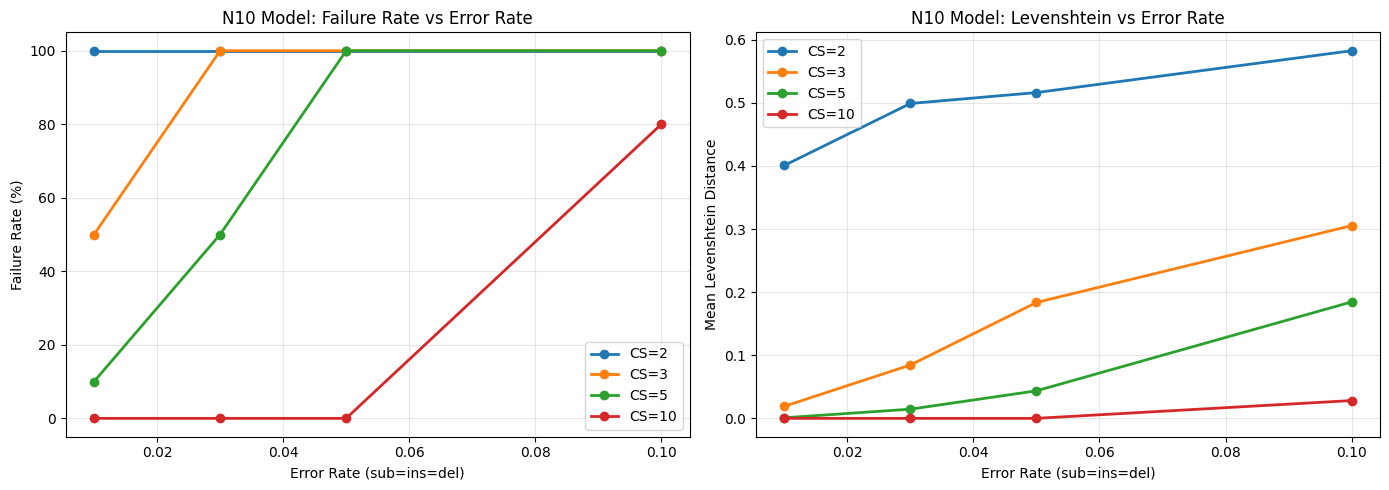

In [4]:
from Levenshtein import distance as lev_dist
from tqdm.notebook import tqdm
from src.eval_pkg.GPT_Inference import GPT_Inference

error_rates = [0.01, 0.03, 0.05, 0.10]
test_cluster_sizes = [2, 3, 5, 10]
n_examples = 10
batch_size = 10

# Set up inference params (same as tutorial/custom_data.ipynb)
ctx = torch.amp.autocast('cuda', dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16)
inf_params = {
    'model': model,
    'ctx': ctx,
    'device': device,
    'stoi': stoi,
    'itos': itos,
    'encode': encode_str,
    'decode': lambda t: ''.join(itos[i] for i in t),
    'temperature': 1.0,
    'greedy': True,
    'ground_truth_length': 110,
    'block_size': 1500,
    'target_type': 'CPRED',
    'constrained_generation': True,
}

results_by_error = {}

for er in error_rates:
    cs_stats = {'substitution_probability': er, 'insertion_probability': er, 'deletion_probability': er}
    results_by_error[er] = {}
    
    for cs in test_cluster_sizes:
        # Generate all examples
        examples = []
        gts = []
        for ex_idx in range(n_examples):
            rng = random.Random(5000 * cs + ex_idx)
            gt = ''.join(rng.choice('ACGT') for _ in range(110))
            reads = [IDS_channel(gt, cs_stats, rng) for _ in range(cs)]
            input_str = '|'.join(reads) + ':'
            examples.append(input_str)
            gts.append(gt)
        
        # Batched inference
        all_preds = []
        with torch.inference_mode(), ctx:
            for batch_start in range(0, len(examples), batch_size):
                batch = examples[batch_start:batch_start + batch_size]
                alignment_sizes = [cs] * len(batch)
                out = GPT_Inference(inf_params).inference(batch, alignment_size=alignment_sizes)
                all_preds.extend(out['candidate_sequences'])
        
        # Compute metrics and print per-example
        levs = []
        for ex_idx, (gt, pred) in enumerate(zip(gts, all_preds)):
            lev = lev_dist(gt, pred[:110]) / 110
            levs.append(lev)
            status = 'OK' if lev == 0 else f'LEV={lev:.3f}'
            print(f'  ER={er:.2f} CS{cs} ex{ex_idx}: {status}')
            print(f'    [GT]   {gt}')
            print(f'    [PRED] {pred[:110]}')
        
        fr = np.mean([l > 0 for l in levs]) * 100
        mean_lev = np.mean(levs)
        results_by_error[er][cs] = {'fr': fr, 'lev': mean_lev}
        print(f'  >> ER={er:.2f} CS={cs}: FR={fr:.1f}%, LEV={mean_lev:.4f}')
        print()

# Print results table
print(f"\n{'':>12}", end='')
for cs in test_cluster_sizes:
    print(f" | CS={cs} FR    CS={cs} LEV ", end='')
print()
print('-' * (12 + len(test_cluster_sizes) * 25))

for er in error_rates:
    print(f"ER={er:>5.2f}    ", end='')
    for cs in test_cluster_sizes:
        s = results_by_error[er][cs]
        print(f" | {s['fr']:>6.1f}%  {s['lev']:>.4f}  ", end='')
    print()

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for cs in test_cluster_sizes:
    frs = [results_by_error[er][cs]['fr'] for er in error_rates]
    levs_plot = [results_by_error[er][cs]['lev'] for er in error_rates]
    ax1.plot(error_rates, frs, 'o-', label=f'CS={cs}', linewidth=2)
    ax2.plot(error_rates, levs_plot, 'o-', label=f'CS={cs}', linewidth=2)

ax1.set_xlabel('Error Rate (sub=ins=del)')
ax1.set_ylabel('Failure Rate (%)')
ax1.set_title('N10 Model: Failure Rate vs Error Rate')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Error Rate (sub=ins=del)')
ax2.set_ylabel('Mean Levenshtein Distance')
ax2.set_title('N10 Model: Levenshtein vs Error Rate')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Comparison: Variable model (N=2-10) vs Fixed N10 model

We run the same experiment with the variable cluster size model (trained on N=2-10)
to see if the collapse at small cluster sizes is specific to the fixed N10 model
or inherent to the problem difficulty.

Variable model (N=2-10) loaded on cuda
  ER=0.01 CS2 ex0:  N10=0.318  VAR=0.018
    [GT]    GAAAAGGCATAGACAGGCAAGATCAGTTGGTTGCAGTTATCTACCTAGAACTTTCGTTCGCGCAACCATCGTCAGCTGGTCGAGACGGGTTAACGGGGATTCCATACTAG
    [N10]   CAAAAAGGAACACACACACACACAAACAAATCAAATACAACAACACACAAACTTTCGTTCGCGCAACCAACATCAGCTGGTCGACACGGGTTAAACGGAAATACATACTA
    [VAR]   GAAAAGGCATAGACAGGCAAGATCAGTTGGTTGCAGTTATCTACCTAGAACTTTCGTTCGCGCAACCATCGTCAGCTGGTCGAGACGGGTTAAACGGGATTCCATACTAG
  ER=0.01 CS2 ex1:  N10=0.445  VAR=0.018
    [GT]    GAATTAGCAGATGCCGGTTGTGTATATGAGAACGAATGGACTGCTATGATATGTACCTCTTTAAGGGAGAGAGCCGGAGCGTCACTGGCGAGGTTTCGAAAGCCTTTGAA
    [N10]   CAATTAGCAGATGACAACTACCAATCACCACAAACAAATGAACTGCTATCATATTTACCACTTTAACGACCACAACAAACACCAACAACCACAAACAAACCAAACCAACA
    [VAR]   GAATTAGCAGATGCCAGTTGTGTATATGAGAACGAATGGACTGCTATGATATTTACCTCTTTAAGGGAGAGAGCCGGAGCGTCACTGGCGAGGTTTCGAAAGCCTTTGAA
  ER=0.01 CS2 ex2:  N10=0.645  VAR=0.018
    [GT]    TCAAGAGCGCGTGATACCAGTAGGCAACGCTGCCTTTAATCCACTTGCTGTAGAATGTAAGTACGGTAGGTTGCAGGAGTTAGCCGTA

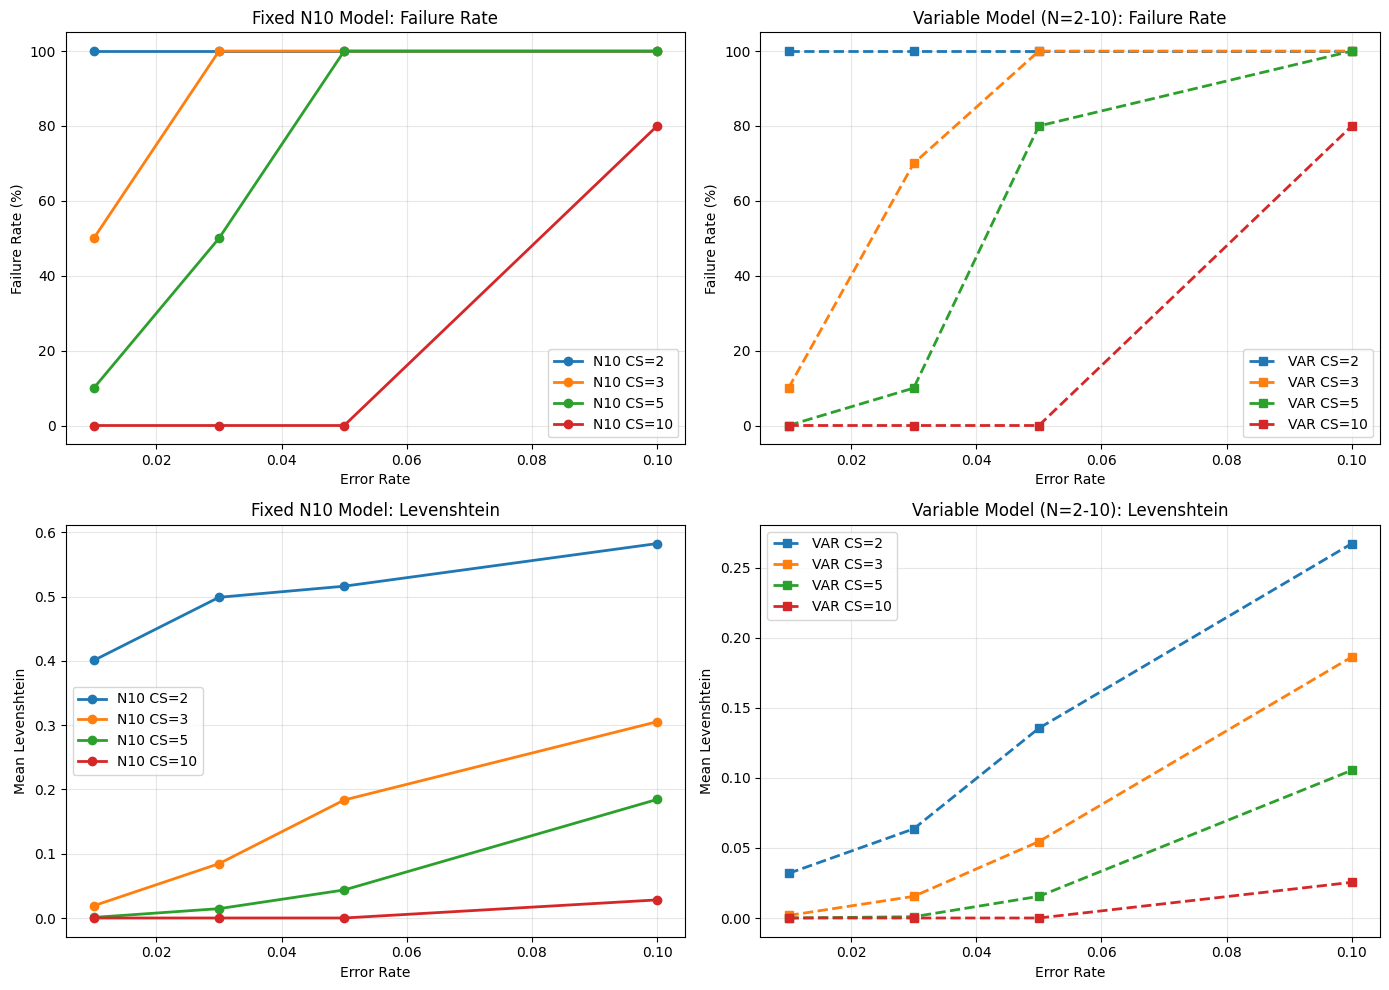

In [5]:
from Levenshtein import distance as lev_dist

# Load variable model (trained on N=2-10)
var_ckpt_path = '/mnt/model_checkpoints/Reproduce/ids_data_nuc_CPRED_obs10_gt110_compute_final_110nt_reproduce/final_110nt_reproduce/train_run_gpt_20250806_100623/checkpoint_best.pt'
var_ckpt = torch.load(var_ckpt_path, map_location=device)
var_state_dict = {k.replace('_orig_mod.', ''): v for k, v in var_ckpt['model'].items()}
var_config_args = {k: v for k, v in var_ckpt['model_args'].items() if k != 'model_type'}
var_model = GPT(GPTConfig(**var_config_args))
var_model.load_state_dict(var_state_dict, strict=True)
var_model = var_model.to(device).eval()
print(f'Variable model (N=2-10) loaded on {device}')

# Inference params for variable model
var_inf_params = {**inf_params, 'model': var_model}

# Run same experiment with both models
results_n10 = {}
results_var = {}

for er in error_rates:
    cs_stats = {'substitution_probability': er, 'insertion_probability': er, 'deletion_probability': er}
    results_n10[er] = {}
    results_var[er] = {}
    
    for cs in test_cluster_sizes:
        examples = []
        gts = []
        for ex_idx in range(n_examples):
            rng = random.Random(5000 * cs + ex_idx)
            gt = ''.join(rng.choice('ACGT') for _ in range(110))
            reads = [IDS_channel(gt, cs_stats, rng) for _ in range(cs)]
            input_str = '|'.join(reads) + ':'
            examples.append(input_str)
            gts.append(gt)
        
        # Batched inference for both models
        preds_n10 = []
        preds_var = []
        with torch.inference_mode(), ctx:
            for batch_start in range(0, len(examples), batch_size):
                batch = examples[batch_start:batch_start + batch_size]
                alignment_sizes = [cs] * len(batch)
                
                out_n10 = GPT_Inference(inf_params).inference(batch, alignment_size=alignment_sizes)
                preds_n10.extend(out_n10['candidate_sequences'])
                
                out_var = GPT_Inference(var_inf_params).inference(batch, alignment_size=alignment_sizes)
                preds_var.extend(out_var['candidate_sequences'])
        
        levs_n10 = []
        levs_var = []
        for ex_idx, (gt, pn10, pvar) in enumerate(zip(gts, preds_n10, preds_var)):
            ln10 = lev_dist(gt, pn10[:110]) / 110
            lvar = lev_dist(gt, pvar[:110]) / 110
            levs_n10.append(ln10)
            levs_var.append(lvar)
            print(f'  ER={er:.2f} CS{cs} ex{ex_idx}:  N10={ln10:.3f}  VAR={lvar:.3f}')
            print(f'    [GT]    {gt}')
            print(f'    [N10]   {pn10[:110]}')
            print(f'    [VAR]   {pvar[:110]}')
        
        fr_n10 = np.mean([l > 0 for l in levs_n10]) * 100
        fr_var = np.mean([l > 0 for l in levs_var]) * 100
        results_n10[er][cs] = {'fr': fr_n10, 'lev': np.mean(levs_n10)}
        results_var[er][cs] = {'fr': fr_var, 'lev': np.mean(levs_var)}
        print(f'  >> ER={er:.2f} CS={cs}: N10 FR={fr_n10:.1f}% LEV={np.mean(levs_n10):.4f}  |  VAR FR={fr_var:.1f}% LEV={np.mean(levs_var):.4f}')
        print()

# Summary table
print(f"\n{'':>12}", end='')
for cs in test_cluster_sizes:
    print(f" | CS={cs} N10    CS={cs} VAR ", end='')
print()
print('-' * (12 + len(test_cluster_sizes) * 26))

for er in error_rates:
    print(f"ER={er:>5.2f} FR ", end='')
    for cs in test_cluster_sizes:
        print(f" | {results_n10[er][cs]['fr']:>5.1f}%  {results_var[er][cs]['fr']:>5.1f}% ", end='')
    print()
    print(f"ER={er:>5.2f} LEV", end='')
    for cs in test_cluster_sizes:
        print(f" | {results_n10[er][cs]['lev']:>.4f}  {results_var[er][cs]['lev']:>.4f} ", end='')
    print()

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for cs in test_cluster_sizes:
    frs_n10 = [results_n10[er][cs]['fr'] for er in error_rates]
    frs_var = [results_var[er][cs]['fr'] for er in error_rates]
    axes[0, 0].plot(error_rates, frs_n10, 'o-', label=f'N10 CS={cs}', linewidth=2)
    axes[0, 1].plot(error_rates, frs_var, 's--', label=f'VAR CS={cs}', linewidth=2)

axes[0, 0].set_title('Fixed N10 Model: Failure Rate')
axes[0, 1].set_title('Variable Model (N=2-10): Failure Rate')

for ax in axes[0]:
    ax.set_xlabel('Error Rate')
    ax.set_ylabel('Failure Rate (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)

for cs in test_cluster_sizes:
    levs_n10_plot = [results_n10[er][cs]['lev'] for er in error_rates]
    levs_var_plot = [results_var[er][cs]['lev'] for er in error_rates]
    axes[1, 0].plot(error_rates, levs_n10_plot, 'o-', label=f'N10 CS={cs}', linewidth=2)
    axes[1, 1].plot(error_rates, levs_var_plot, 's--', label=f'VAR CS={cs}', linewidth=2)

axes[1, 0].set_title('Fixed N10 Model: Levenshtein')
axes[1, 1].set_title('Variable Model (N=2-10): Levenshtein')

for ax in axes[1]:
    ax.set_xlabel('Error Rate')
    ax.set_ylabel('Mean Levenshtein')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [6]:
# Zero error: reads are exact copies of the ground truth
# If the N10 model still fails on CS2 with perfect reads, it's purely a model issue
from Levenshtein import distance as lev_dist

test_cluster_sizes = [2, 3, 5, 10]
n_examples = 50

print("Zero-error reads (reads = exact copies of GT)")
print("=" * 80)

for cs in test_cluster_sizes:
    examples, gts = [], []
    for i in range(n_examples):
        rng = random.Random(7000 * cs + i)
        gt = ''.join(rng.choice('ACGT') for _ in range(110))
        # No error channel — reads are exact copies of GT
        reads = [gt] * cs
        examples.append('|'.join(reads) + ':')
        gts.append(gt)
    
    pn10, pvar = [], []
    with torch.inference_mode(), ctx:
        for bs in range(0, len(examples), batch_size):
            batch = examples[bs:bs+batch_size]
            asizes = [cs] * len(batch)
            pn10.extend(GPT_Inference(inf_params).inference(batch, alignment_size=asizes)['candidate_sequences'])
            pvar.extend(GPT_Inference(var_inf_params).inference(batch, alignment_size=asizes)['candidate_sequences'])
    
    ln10 = [lev_dist(g, p[:110])/110 for g, p in zip(gts, pn10)]
    lvar = [lev_dist(g, p[:110])/110 for g, p in zip(gts, pvar)]
    fn10 = np.mean([l>0 for l in ln10])*100
    fvar = np.mean([l>0 for l in lvar])*100
    
    print(f"CS={cs}: N10 FR={fn10:.1f}% LEV={np.mean(ln10):.4f} | VAR FR={fvar:.1f}% LEV={np.mean(lvar):.4f}")
    
    # Show examples for CS2
    if cs == 2:
        for j in range(min(5, n_examples)):
            print(f"  [GT]  {gts[j]}")
            print(f"  [N10] {pn10[j][:110]}")
            print(f"  [VAR] {pvar[j][:110]}")
            print(f"  N10={ln10[j]:.3f} VAR={lvar[j]:.3f}")


Zero-error reads (reads = exact copies of GT)
CS=2: N10 FR=98.0% LEV=0.3804 | VAR FR=0.0% LEV=0.0000
  [GT]  CCCGCGACTCAACTTCATTGTTGCTACTCACTCCATTTAAGAGAGATTTCTGCTATGGCTTAGGATGATACCACCTGACTCTACCCGTTAGCGCCCAGCGTATTCCCCGG
  [N10] CCCACAACACAACAAAAAACAAAAAAAAACAAAACAACACACAAACAAAAACCACCAACAAACAAAAACACACAAACAACCAACAACAACAACAACAAACAAAAACCCCA
  [VAR] CCCGCGACTCAACTTCATTGTTGCTACTCACTCCATTTAAGAGAGATTTCTGCTATGGCTTAGGATGATACCACCTGACTCTACCCGTTAGCGCCCAGCGTATTCCCCGG
  N10=0.609 VAR=0.000
  [GT]  TGGCGAGACCCAAACATACACCAATTACCAGAACCCTTGTGAGCCACTCGCTGTTGGAATCTACCAGACACGACAGCATACGGCGCACATAATAATCCGGTAATTGTTTC
  [N10] CCCACAACCAAACAAACACCAATTACCAGAACCCTTGTGAGCCACTCGCTGTTGAACCAACCACACACACCAACAACAACAACAACAACAACAAACACAAAAAACAAAAA
  [VAR] TGGCGAGACCCAAACATACACCAATTACCAGAACCCTTGTGAGCCACTCGCTGTTGGAATCTACCAGACACGACAGCATACGGCGCACATAATAATCCGGTAATTGTTTC
  N10=0.318 VAR=0.000
  [GT]  ATCCTCCGTCGGGTTTTTTGTCAGGCAGGATCCAATAGGGAGAATCACCTTACTAAAACATTTAATCCCAGTTAGATCGGAATGAGGCTAGGTACAGTCCCGCGCGACCA
  [N10] ATCCTCCGTCGGAT

In [7]:
# Duplicate last read to make CS2 look like CS3
# If the model recovers, the threshold is between position ~220 and ~330
from Levenshtein import distance as lev_dist

n_examples = 50
error_rates_test = [0.0, 0.01, 0.05]

print("CS=2 with duplicated last read (artificial CS=3)")
print("=" * 80)

for er in error_rates_test:
    cs_stats = {'substitution_probability': er, 'insertion_probability': er, 'deletion_probability': er}
    
    examples_real2, examples_fake3, gts = [], [], []
    for i in range(n_examples):
        rng = random.Random(8000 + i)
        gt = ''.join(rng.choice('ACGT') for _ in range(110))
        if er == 0.0:
            reads = [gt, gt]
        else:
            reads = [IDS_channel(gt, cs_stats, rng) for _ in range(2)]
        
        # Real CS=2
        examples_real2.append('|'.join(reads) + ':')
        # Fake CS=3: duplicate last read
        examples_fake3.append('|'.join(reads + [reads[-1]]) + ':')
        gts.append(gt)
    
    # Inference
    preds_real2, preds_fake3 = [], []
    with torch.inference_mode(), ctx:
        for bs in range(0, len(examples_real2), batch_size):
            batch2 = examples_real2[bs:bs+batch_size]
            batch3 = examples_fake3[bs:bs+batch_size]
            preds_real2.extend(GPT_Inference(inf_params).inference(batch2, alignment_size=[2]*len(batch2))['candidate_sequences'])
            preds_fake3.extend(GPT_Inference(inf_params).inference(batch3, alignment_size=[3]*len(batch3))['candidate_sequences'])
    
    l2 = [lev_dist(g, p[:110])/110 for g, p in zip(gts, preds_real2)]
    l3 = [lev_dist(g, p[:110])/110 for g, p in zip(gts, preds_fake3)]
    fr2 = np.mean([l>0 for l in l2])*100
    fr3 = np.mean([l>0 for l in l3])*100
    
    er_label = "zero" if er == 0.0 else f"{er:.2f}"
    print(f"ER={er_label}: Real CS=2 FR={fr2:.1f}% LEV={np.mean(l2):.4f} | Fake CS=3 FR={fr3:.1f}% LEV={np.mean(l3):.4f}")
    
    # Show examples
    for j in range(min(3, n_examples)):
        print(f"  [GT]      {gts[j]}")
        print(f"  [CS=2]    {preds_real2[j][:110]}")
        print(f"  [fake CS3]{preds_fake3[j][:110]}")
        print(f"  CS2 LEV={l2[j]:.3f}  fakeCS3 LEV={l3[j]:.3f}")
    print()


CS=2 with duplicated last read (artificial CS=3)
ER=zero: Real CS=2 FR=100.0% LEV=0.3509 | Fake CS=3 FR=4.0% LEV=0.0005
  [GT]      GAGAGTACCAAACGTAACGGTCTACTATACGATAAAATATGCGCCTGTTGGGTACCGCACGATGCTCCTCACAATGCGCGTATAACTTGCCTGACGGATAAGTCGCAACT
  [CS=2]    CCACACACATCAAACACCAACAAACAAAACACCACAAAAAACACACAAATCAAACACAAAACACCTCACAATGCGCGTATAACTTGCCTCACGAACAAGTCGCAACACAA
  [fake CS3]GAGAGTACCAAACGTAACGGTCTACTATACGATAAAATATGCGCCTGTTGGGTACCGCACGATGCTCCTCACAATGCGCGTATAACTTGCCTGACGGATAAGTCGCAACT
  CS2 LEV=0.409  fakeCS3 LEV=0.000
  [GT]      GCTTCGAACAATGCACTGACCTAGGGACCGGGCGCTGTTTGACAGATTGGTTGCACCTTCACGCGTGCCGAGGCATTATGTAACGTACACCGAGAAAAGTGGGATCTCAT
  [CS=2]    CACTACAAACAACCAAAACAACACAAACAAAAAAAACCACACAATCCCAAACACACACACACACACAACCACAACAAAACACACAAAAACAACAAAAAAACAACCACAAA
  [fake CS3]GCTTCGAACAATGCACTGACCTAGGGACCGGGCGCTGTTTGACAGATTGGTTGCACCTTCACGCGTGCCGAGGCATTATGTAACGTACACCGAGAAAAGTGGGATCTCAT
  CS2 LEV=0.618  fakeCS3 LEV=0.000
  [GT]      CTTCCGGTCCGGAAACACGTGTCGCTCACCATTAGTCTGTGATAGCCGTTTGCGAAAAAT